In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
demanddata_2021 = pd.read_csv('Figure1_Needs/demanddata_2021.csv')

In [3]:
demanddata_2021.head()

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
0,01-JAN-2021,1,28354,28969,26130,1158,6527,0,13471,0,...,2003,-1,0,215,203,999,0,0,0,0
1,01-JAN-2021,2,28501,29114,26281,1208,6527,0,13471,0,...,2004,-1,0,359,203,999,0,0,0,0
2,01-JAN-2021,3,27759,28376,25557,1202,6527,0,13471,0,...,2004,-1,0,362,202,999,0,0,0,0
3,01-JAN-2021,4,26912,27749,24792,1226,6527,0,13471,0,...,2004,-1,0,361,203,1000,0,0,0,0
4,01-JAN-2021,5,26004,27178,23933,1193,6527,0,13471,0,...,2004,-1,0,304,203,1000,0,0,0,0


In [4]:
# Select the required columns
selected_data = demanddata_2021[["ND", "EMBEDDED_SOLAR_GENERATION"]]
# Display the first few rows
selected_data.head()

,ND,EMBEDDED_SOLAR_GENERATION
0,28354,0
1,28501,0
2,27759,0
3,26912,0
4,26004,0


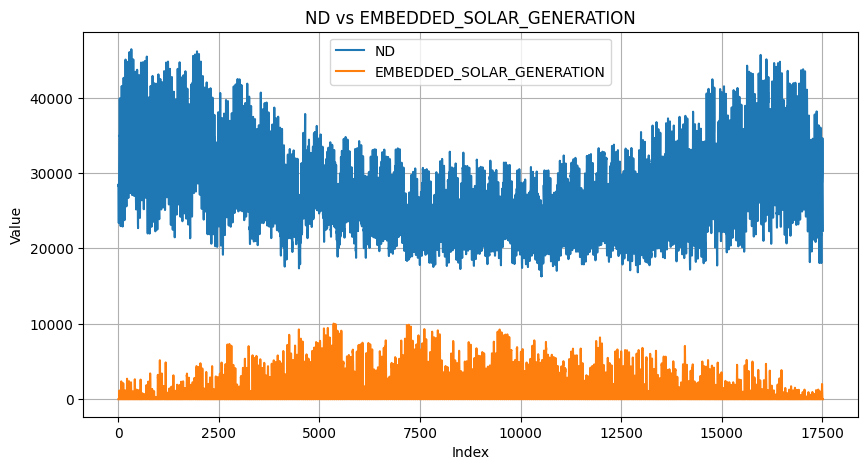

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(selected_data["ND"], label="ND")
plt.plot(selected_data["EMBEDDED_SOLAR_GENERATION"], label="EMBEDDED_SOLAR_GENERATION")
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("ND vs EMBEDDED_SOLAR_GENERATION")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Example: If data is sampled every 30 minutes, there are 48 time steps per day
num_days = 365
num_time_steps = len(selected_data) // num_days

# Reshape ND and EMBEDDED_SOLAR_GENERATION into [day, time] matrices
ND_matrix = selected_data["ND"].values.reshape(num_days, num_time_steps)
SOLAR_matrix = selected_data["EMBEDDED_SOLAR_GENERATION"].values.reshape(num_days, num_time_steps)

# Check the shape
print("ND_matrix shape:", ND_matrix.shape)
print("SOLAR_matrix shape:", SOLAR_matrix.shape)

# Sum across each day (axis=1)
ND_daily_sum = ND_matrix.sum(axis=1)
SOLAR_daily_sum = SOLAR_matrix.sum(axis=1)

# Number of weeks in a year (assuming 365 days)
num_weeks = 52
# Truncate to full weeks if needed
days_per_week = 7
total_days = num_weeks * days_per_week
ND_weekly_sum = ND_daily_sum[:total_days].reshape(num_weeks, days_per_week).sum(axis=1)
SOLAR_weekly_sum = SOLAR_daily_sum[:total_days].reshape(num_weeks, days_per_week).sum(axis=1)

ND_matrix shape: (365, 48)
SOLAR_matrix shape: (365, 48)


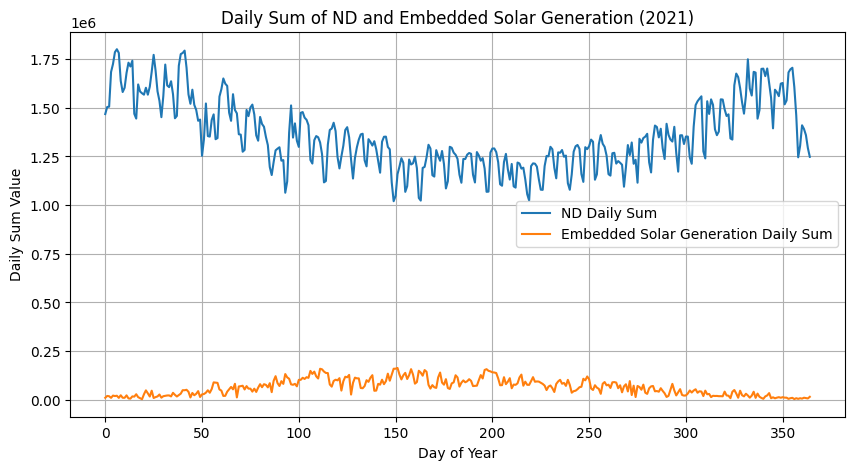

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(ND_daily_sum, label="ND Daily Sum")
plt.plot(SOLAR_daily_sum, label="Embedded Solar Generation Daily Sum")
plt.xlabel("Day of Year")
plt.ylabel("Daily Sum Value")
plt.title("Daily Sum of ND and Embedded Solar Generation (2021)")
plt.legend()
plt.grid(True)
plt.show()

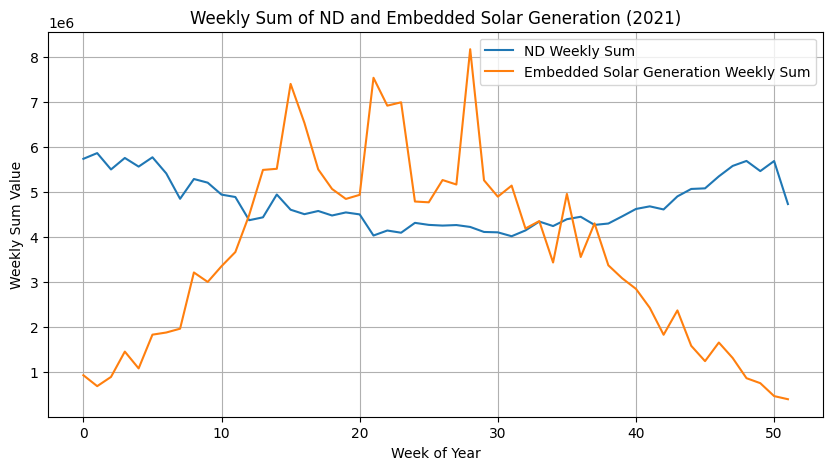

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(ND_weekly_sum*0.5, label="ND Weekly Sum")
plt.plot(SOLAR_weekly_sum*8, label="Embedded Solar Generation Weekly Sum")
plt.xlabel("Week of Year")
plt.ylabel("Weekly Sum Value")
plt.title("Weekly Sum of ND and Embedded Solar Generation (2021)")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
import pandas as pd

# Create a DataFrame for weekly data
weekly_data = pd.DataFrame({
    "ND_weekly_sum": ND_weekly_sum*0.5,
    "SOLAR_weekly_sum": SOLAR_weekly_sum*8
})

# Export to Excel
weekly_data.to_excel("weekly_sum_data.xlsx", index_label="Week")